# Evolução do Desemprego no Brasil (2015 a 2024)

**Avaliação G1 · Disciplina: Linguagens de Programação**
**Professor:** Alexandre Neves Louzada
**Tema 04 · Evolução do Desemprego no Brasil**
**Aluno:** Marcell Sidaco de Moraes

Este notebook documenta todo o fluxo analítico do projeto: leitura, limpeza, engenharia de atributos,
persistência em banco SQLite com SQLAlchemy, análise exploratória, KPIs, gráficos, interpretação e conclusão.
Os arquivos gerados aqui (CSV tratado, banco, malha geográfica e imagens) alimentam o dashboard Streamlit
e a página do projeto no GitHub Pages.

**Sumário**
1. Introdução ao problema
2. Contextualização econômica
3. Explicação da base de dados
4. Leitura dos dados
5. Limpeza e preparação
6. Engenharia de atributos
7. Análise exploratória
8. KPIs
9. Gráficos
10. Interpretação dos resultados
11. Conclusão

## 1. Introdução ao problema

O desemprego é um dos principais indicadores socioeconômicos de um país. Ele afeta diretamente a qualidade de
vida, a renda das famílias, o consumo, o desenvolvimento regional e o crescimento econômico.

O objetivo deste projeto é investigar o comportamento do desemprego no Brasil entre 2015 e 2024 para:

* analisar tendências econômicas;
* identificar as regiões mais afetadas;
* comparar estados;
* investigar períodos de crise e de recuperação econômica;
* construir visualizações interativas.

**Perguntas orientadoras**

1. Quais regiões apresentam maior desemprego?
2. Quais estados apresentam menores taxas?
3. Existem períodos de crise econômica mais evidentes?
4. O desemprego aumentou ou diminuiu ao longo do tempo?
5. Existem diferenças relevantes entre regiões?
6. Há sazonalidade em determinados setores?
7. Quais grupos parecem mais vulneráveis?

## 2. Contextualização econômica

O período de 2015 a 2024 reúne momentos muito distintos da economia brasileira:

* **2015 e 2016:** recessão, com queda do PIB, aumento do desemprego e inflação elevada.
* **2017 a 2019:** recuperação lenta, com o desemprego ainda alto mas em queda gradual.
* **2020 e 2021:** pandemia de Covid-19, com fechamento de atividades e forte impacto sobre o emprego,
  principalmente em comércio e serviços.
* **2022 a 2024:** reabertura e recuperação do mercado de trabalho, com redução da taxa de desemprego.

Além do tempo, o desemprego no Brasil tem um componente regional marcante: historicamente Norte e Nordeste
registram taxas maiores que Sul e Centro-Oeste, reflexo de diferenças na estrutura produtiva, na
formalização e na renda. A base usada aqui é **simulada** pelo professor, mas segue esse comportamento
geral, o que permite praticar a análise sem depender de dados oficiais.

## 3. Explicação da base de dados

Arquivo: `dados/simulacao_desemprego_brasil.csv`, fornecido no repositório
[Dados-Simulados-G2](https://github.com/AlexandreLouzada/Dados-Simulados-G2).
Cada linha representa **um estado em um trimestre**.

| Coluna | Descrição |
|---|---|
| `ano` | Ano da ocorrência |
| `trimestre` | Trimestre da pesquisa (1 a 4) |
| `data` | Data de referência (último mês do trimestre) |
| `regiao` | Região do Brasil |
| `uf` | Sigla do estado |
| `populacao_ativa` | População economicamente ativa |
| `empregados` | Número de empregados |
| `desempregados` | Número de desempregados |
| `taxa_desemprego` | Percentual de desemprego |
| `renda_media` | Renda média mensal (R$) |
| `setor_predominante` | Principal setor econômico no trimestre |
| `vagas_formais` | Novas vagas formais |
| `inflacao` | Índice de inflação (%) |
| `nivel_risco` | Baixo, Médio, Alto ou Crítico |

## 4. Leitura dos dados

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DADOS = BASE / "dados"
IMAGENS = BASE / "imagens"
DATABASE = BASE / "database"
IMAGENS.mkdir(exist_ok=True)
DATABASE.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

df_bruto = pd.read_csv(DADOS / "simulacao_desemprego_brasil.csv")
print(f"Linhas: {df_bruto.shape[0]} | Colunas: {df_bruto.shape[1]}")
df_bruto.head()

Linhas: 800 | Colunas: 14


,ano,trimestre,data,regiao,uf,populacao_ativa,empregados,desempregados,taxa_desemprego,renda_media,setor_predominante,vagas_formais,inflacao,nivel_risco
0,2015,1,2015-03-01,Norte,AM,1428772,1293887,134885,9.44,"2,539.67",Construção,9513,7.09,Médio
1,2015,1,2015-03-01,Norte,PA,4912808,4231410,681398,13.87,"2,536.28",Construção,3104,6.84,Alto
2,2015,1,2015-03-01,Norte,RO,3654834,3217078,437756,11.98,"3,185.87",Construção,57505,5.48,Alto
3,2015,1,2015-03-01,Norte,TO,3481897,3010863,471034,13.53,"1,933.31",Comércio,61208,6.76,Alto
4,2015,1,2015-03-01,Nordeste,BA,509015,425557,83458,16.40,"3,792.59",Serviços,47983,5.51,Crítico


In [2]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ano                 800 non-null    int64  
 1   trimestre           800 non-null    int64  
 2   data                800 non-null    str    
 3   regiao              800 non-null    str    
 4   uf                  800 non-null    str    
 5   populacao_ativa     800 non-null    int64  
 6   empregados          800 non-null    int64  
 7   desempregados       800 non-null    int64  
 8   taxa_desemprego     800 non-null    float64
 9   renda_media         800 non-null    float64
 10  setor_predominante  800 non-null    str    
 11  vagas_formais       800 non-null    int64  
 12  inflacao            800 non-null    float64
 13  nivel_risco         800 non-null    str    
dtypes: float64(3), int64(6), str(5)
memory usage: 115.2 KB


In [3]:
df_bruto.describe().T

,count,mean,std,min,25%,50%,75%,max
ano,800.00,"2,019.50",2.87,"2,015.00","2,017.00","2,019.50","2,022.00","2,024.00"
trimestre,800.00,2.50,1.12,1.00,1.75,2.50,3.25,4.00
populacao_ativa,800.00,"3,217,270.65","1,650,285.63","318,431.00","1,756,632.25","3,332,223.00","4,644,644.00","5,999,399.00"
empregados,800.00,"2,899,966.75","1,492,184.44","275,629.00","1,583,077.50","2,999,189.00","4,163,297.25","5,665,164.00"
desempregados,800.00,"317,303.90","198,400.48","15,257.00","153,360.75","296,823.00","451,212.00","923,101.00"
taxa_desemprego,800.00,9.90,3.23,3.00,7.56,9.82,12.27,20.53
renda_media,800.00,"2,790.65",581.40,"1,002.32","2,396.18","2,815.15","3,176.67","4,691.42"
vagas_formais,800.00,"44,820.77","25,624.24","1,063.00","22,070.25","44,946.50","66,820.25","89,691.00"
inflacao,800.00,4.98,1.58,-1.06,3.92,4.96,6.04,9.90


In [4]:
for coluna in ["ano", "trimestre", "regiao", "uf", "setor_predominante", "nivel_risco"]:
    print(coluna, "->", df_bruto[coluna].nunique(), "valores:", sorted(df_bruto[coluna].unique()))

ano -> 10 valores: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
trimestre -> 4 valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
regiao -> 5 valores: ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
uf -> 20 valores: ['AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PR', 'RJ', 'RO', 'RS', 'SC', 'SP', 'TO']
setor_predominante -> 5 valores: ['Agropecuária', 'Comércio', 'Construção', 'Indústria', 'Serviços']
nivel_risco -> 4 valores: ['Alto', 'Baixo', 'Crítico', 'Médio']


A base tem 800 registros: **20 estados x 40 trimestres** (2015 a 2024). Estão presentes 4 estados do Norte,
5 do Nordeste, 4 do Centro-Oeste, 4 do Sudeste e 3 do Sul. Os estados ausentes (por exemplo AC, AP, RR, AL,
SE, RN, PI) ficam fora da análise e aparecem em branco no mapa.

## 5. Limpeza e preparação

Etapas aplicadas:

1. Verificação de valores nulos e registros duplicados.
2. Verificação de chave única (um registro por estado e trimestre).
3. Conversão de tipos: `data` para datetime e categorias ordenadas.
4. Validação de consistência: `empregados + desempregados = populacao_ativa` e taxa recalculada.
5. Padronização de textos (espaços e capitalização).
6. Verificação de faixas válidas e detecção de outliers (método IQR).

In [5]:
df = df_bruto.copy()

print("Valores nulos por coluna:")
print(df.isna().sum().to_string())
print("\nLinhas duplicadas:", df.duplicated().sum())
print("Duplicidades de estado + trimestre:", df.duplicated(subset=["uf", "ano", "trimestre"]).sum())

Valores nulos por coluna:
ano                   0
trimestre             0
data                  0
regiao                0
uf                    0
populacao_ativa       0
empregados            0
desempregados         0
taxa_desemprego       0
renda_media           0
setor_predominante    0
vagas_formais         0
inflacao              0
nivel_risco           0

Linhas duplicadas: 0
Duplicidades de estado + trimestre: 0


In [6]:
# Padronização de textos
for coluna in ["regiao", "uf", "setor_predominante", "nivel_risco"]:
    df[coluna] = df[coluna].str.strip()
df["uf"] = df["uf"].str.upper()

# Tipos
df["data"] = pd.to_datetime(df["data"], format="%Y-%m-%d")
ORDEM_RISCO = ["Baixo", "Médio", "Alto", "Crítico"]
ORDEM_REGIOES = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
df["nivel_risco"] = pd.Categorical(df["nivel_risco"], ORDEM_RISCO, ordered=True)
df["regiao"] = pd.Categorical(df["regiao"], ORDEM_REGIOES, ordered=True)

# Data deve corresponder ao ano e ao último mês do trimestre
data_ok = (df["data"].dt.year == df["ano"]) & (df["data"].dt.month == df["trimestre"] * 3)
print("Datas coerentes com ano/trimestre:", data_ok.all())
df.dtypes

Datas coerentes com ano/trimestre: True


ano                            int64
trimestre                      int64
data                  datetime64[us]
regiao                      category
uf                               str
populacao_ativa                int64
empregados                     int64
desempregados                  int64
taxa_desemprego              float64
renda_media                  float64
setor_predominante               str
vagas_formais                  int64
inflacao                     float64
nivel_risco                 category
dtype: object

In [7]:
# Consistência entre colunas
soma_ok = (df["empregados"] + df["desempregados"] == df["populacao_ativa"])
taxa_recalculada = df["desempregados"] / df["populacao_ativa"] * 100
diferenca_taxa = (taxa_recalculada - df["taxa_desemprego"]).abs()

print("Empregados + desempregados = população ativa:", soma_ok.all())
print(f"Maior diferença entre taxa informada e recalculada: {diferenca_taxa.max():.4f} p.p.")

# Faixas válidas
print("Taxas entre 0 e 100%:", df["taxa_desemprego"].between(0, 100).all())
print("Valores negativos em contagens:", (df[["populacao_ativa", "empregados", "desempregados", "vagas_formais"]] < 0).any().any())
print("Registros com inflação negativa (deflação):", (df["inflacao"] < 0).sum())

Empregados + desempregados = população ativa: True
Maior diferença entre taxa informada e recalculada: 0.0051 p.p.
Taxas entre 0 e 100%: True
Valores negativos em contagens: False
Registros com inflação negativa (deflação): 2


A taxa informada difere da recalculada em menos de 0,01 p.p., apenas por arredondamento, então a coluna
original é mantida. A inflação negativa em poucos registros representa deflação e é um valor possível,
por isso também foi mantida.

In [8]:
# Outliers pelo método IQR
def outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return serie[(serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)]

numericas = ["taxa_desemprego", "renda_media", "inflacao", "vagas_formais", "populacao_ativa"]
resumo_outliers = pd.Series({c: len(outliers_iqr(df[c])) for c in numericas}, name="outliers")
resumo_outliers

taxa_desemprego    1
renda_media        4
inflacao           9
vagas_formais      0
populacao_ativa    0
Name: outliers, dtype: int64

In [9]:
out_taxa = outliers_iqr(df["taxa_desemprego"])
df.loc[out_taxa.index, ["ano", "trimestre", "uf", "regiao", "taxa_desemprego", "nivel_risco"]].sort_values("taxa_desemprego", ascending=False)

,ano,trimestre,uf,regiao,taxa_desemprego,nivel_risco
688,2023,3,PB,Nordeste,20.53,Crítico


Os valores extremos de taxa de desemprego pertencem a estados do Nordeste classificados como risco
**Crítico**. Eles são observações legítimas (justamente o fenômeno que queremos estudar), então não
foram removidos.

Também conferimos como o `nivel_risco` foi definido: ele segue faixas da taxa de desemprego.

In [10]:
df.groupby("nivel_risco", observed=True)["taxa_desemprego"].agg(["min", "max", "count"])

,min,max,count
nivel_risco,,,
Baixo,3.00,7.00,150
Médio,7.00,9.98,269
Alto,10.01,13.99,289
Crítico,14.02,20.53,92


Faixas observadas: **Baixo** abaixo de 7%, **Médio** de 7% a 10%, **Alto** de 10% a 14% e **Crítico**
acima de 14%.

## 6. Engenharia de atributos

Novas colunas criadas:

| Atributo | Descrição |
|---|---|
| `estado` | Nome completo da UF (API de localidades do IBGE) |
| `codigo_ibge` | Código IBGE da UF, usado para ligar com o mapa |
| `periodo` | Rótulo do trimestre, ex. `2020-T2` |
| `taxa_ocupacao` | Percentual de empregados na população ativa |
| `variacao_taxa_anual` | Diferença em p.p. para o mesmo trimestre do ano anterior |
| `media_movel_4t` | Média móvel de 4 trimestres da taxa, por estado |
| `faixa_renda` | Faixa da renda média mensal |
| `fase_economica` | Crise 2015-2016, Pré-pandemia, Pandemia, Recuperação |

In [11]:
# Nome e código IBGE dos estados via API pública do IBGE (com alternativa local se a API falhar)
UFS_RESERVA = {
    "AM": ("Amazonas", 13), "PA": ("Pará", 15), "RO": ("Rondônia", 11), "TO": ("Tocantins", 17),
    "BA": ("Bahia", 29), "PE": ("Pernambuco", 26), "CE": ("Ceará", 23), "MA": ("Maranhão", 21),
    "PB": ("Paraíba", 25), "DF": ("Distrito Federal", 53), "GO": ("Goiás", 52),
    "MT": ("Mato Grosso", 51), "MS": ("Mato Grosso do Sul", 50), "SP": ("São Paulo", 35),
    "RJ": ("Rio de Janeiro", 33), "MG": ("Minas Gerais", 31), "ES": ("Espírito Santo", 32),
    "PR": ("Paraná", 41), "SC": ("Santa Catarina", 42), "RS": ("Rio Grande do Sul", 43),
}
try:
    resposta = requests.get("https://servicodados.ibge.gov.br/api/v1/localidades/estados", timeout=20)
    resposta.raise_for_status()
    ufs_ibge = {e["sigla"]: (e["nome"], e["id"]) for e in resposta.json()}
    print("Estados obtidos da API do IBGE:", len(ufs_ibge))
except requests.RequestException as erro:
    ufs_ibge = UFS_RESERVA
    print("API indisponível, usando tabela local:", erro)

df["estado"] = df["uf"].map(lambda u: ufs_ibge[u][0])
df["codigo_ibge"] = df["uf"].map(lambda u: ufs_ibge[u][1]).astype(int)

Estados obtidos da API do IBGE: 27


In [12]:
df = df.sort_values(["uf", "data"]).reset_index(drop=True)

df["periodo"] = df["ano"].astype(str) + "-T" + df["trimestre"].astype(str)
df["taxa_ocupacao"] = (df["empregados"] / df["populacao_ativa"] * 100).round(2)
df["variacao_taxa_anual"] = df.groupby("uf")["taxa_desemprego"].diff(4).round(2)
df["media_movel_4t"] = (
    df.groupby("uf")["taxa_desemprego"].transform(lambda s: s.rolling(4).mean()).round(2)
)
df["faixa_renda"] = pd.cut(
    df["renda_media"], bins=[0, 2000, 3000, 4000, np.inf],
    labels=["Até R$ 2 mil", "R$ 2 a 3 mil", "R$ 3 a 4 mil", "Acima de R$ 4 mil"],
)

def fase_economica(ano):
    if ano <= 2016:
        return "Crise 2015-2016"
    if ano <= 2019:
        return "Pré-pandemia"
    if ano <= 2021:
        return "Pandemia"
    return "Recuperação"

df["fase_economica"] = df["ano"].apply(fase_economica)

df[["periodo", "uf", "estado", "taxa_desemprego", "taxa_ocupacao", "variacao_taxa_anual",
    "media_movel_4t", "faixa_renda", "fase_economica"]].head(8)

,periodo,uf,estado,taxa_desemprego,taxa_ocupacao,variacao_taxa_anual,media_movel_4t,faixa_renda,fase_economica
0,2015-T1,AM,Amazonas,9.44,90.56,NaN,NaN,R$ 2 a 3 mil,Crise 2015-2016
1,2015-T2,AM,Amazonas,7.84,92.16,NaN,NaN,Até R$ 2 mil,Crise 2015-2016
2,2015-T3,AM,Amazonas,12.85,87.15,NaN,NaN,R$ 2 a 3 mil,Crise 2015-2016
3,2015-T4,AM,Amazonas,10.58,89.42,NaN,10.18,R$ 3 a 4 mil,Crise 2015-2016
4,2016-T1,AM,Amazonas,11.48,88.52,2.04,10.69,R$ 3 a 4 mil,Crise 2015-2016
5,2016-T2,AM,Amazonas,11.19,88.81,3.35,11.52,Até R$ 2 mil,Crise 2015-2016
6,2016-T3,AM,Amazonas,15.53,84.47,2.68,12.20,R$ 3 a 4 mil,Crise 2015-2016
7,2016-T4,AM,Amazonas,13.04,86.96,2.46,12.81,R$ 2 a 3 mil,Crise 2015-2016


As primeiras linhas de cada estado ficam sem `variacao_taxa_anual` (não existe trimestre do ano anterior a
2015) e sem `media_movel_4t` (são necessários 4 trimestres). Esses vazios são esperados e não afetam as
demais análises.

### Persistência: CSV tratado, banco SQLite (SQLAlchemy) e malha geográfica

A base tratada é salva em CSV e também em um **banco SQLite com modelagem relacional** criado com o ORM do
SQLAlchemy:

* `regiao` (1) ── (N) `uf`
* `uf` (1) ── (N) `indicador_trimestral`
* `setor` (1) ── (N) `indicador_trimestral`

O dashboard lê os dados com uma consulta SQL que faz JOIN entre as quatro tabelas.

In [13]:
df.to_csv(DADOS / "simulacao_desemprego_brasil_tratado.csv", index=False)
print("CSV tratado salvo:", (DADOS / "simulacao_desemprego_brasil_tratado.csv").name)

CSV tratado salvo: simulacao_desemprego_brasil_tratado.csv


In [14]:
from sqlalchemy import Date, Float, ForeignKey, Integer, String, create_engine, func, select, text
from sqlalchemy.orm import DeclarativeBase, Mapped, Session, mapped_column, relationship


class Base(DeclarativeBase):
    pass


class Regiao(Base):
    __tablename__ = "regiao"
    id: Mapped[int] = mapped_column(primary_key=True)
    nome: Mapped[str] = mapped_column(String(20), unique=True)
    ufs: Mapped[list["UF"]] = relationship(back_populates="regiao")


class UF(Base):
    __tablename__ = "uf"
    id: Mapped[int] = mapped_column(primary_key=True)
    sigla: Mapped[str] = mapped_column(String(2), unique=True)
    nome: Mapped[str] = mapped_column(String(40))
    codigo_ibge: Mapped[int] = mapped_column(Integer, unique=True)
    regiao_id: Mapped[int] = mapped_column(ForeignKey("regiao.id"))
    regiao: Mapped[Regiao] = relationship(back_populates="ufs")
    indicadores: Mapped[list["IndicadorTrimestral"]] = relationship(back_populates="uf")


class Setor(Base):
    __tablename__ = "setor"
    id: Mapped[int] = mapped_column(primary_key=True)
    nome: Mapped[str] = mapped_column(String(30), unique=True)


class IndicadorTrimestral(Base):
    __tablename__ = "indicador_trimestral"
    id: Mapped[int] = mapped_column(primary_key=True)
    uf_id: Mapped[int] = mapped_column(ForeignKey("uf.id"))
    setor_id: Mapped[int] = mapped_column(ForeignKey("setor.id"))
    ano: Mapped[int]
    trimestre: Mapped[int]
    data: Mapped["Date"] = mapped_column(Date)
    periodo: Mapped[str] = mapped_column(String(7))
    populacao_ativa: Mapped[int]
    empregados: Mapped[int]
    desempregados: Mapped[int]
    taxa_desemprego: Mapped[float] = mapped_column(Float)
    taxa_ocupacao: Mapped[float] = mapped_column(Float)
    renda_media: Mapped[float] = mapped_column(Float)
    vagas_formais: Mapped[int]
    inflacao: Mapped[float] = mapped_column(Float)
    nivel_risco: Mapped[str] = mapped_column(String(10))
    variacao_taxa_anual: Mapped[float | None] = mapped_column(Float, nullable=True)
    media_movel_4t: Mapped[float | None] = mapped_column(Float, nullable=True)
    faixa_renda: Mapped[str] = mapped_column(String(20))
    fase_economica: Mapped[str] = mapped_column(String(20))
    uf: Mapped[UF] = relationship(back_populates="indicadores")
    setor: Mapped[Setor] = relationship()


CAMINHO_BANCO = DATABASE / "desemprego.sqlite"
CAMINHO_BANCO.unlink(missing_ok=True)
engine = create_engine(f"sqlite:///{CAMINHO_BANCO}")
Base.metadata.create_all(engine)

In [15]:
def valor(v):
    """Converte NaN para None (NULL no banco) e tipos NumPy para Python."""
    if pd.isna(v):
        return None
    return v.item() if hasattr(v, "item") else v


with Session(engine) as sessao:
    regioes = {nome: Regiao(nome=nome) for nome in ORDEM_REGIOES}
    setores = {nome: Setor(nome=nome) for nome in sorted(df["setor_predominante"].unique())}
    ufs = {}
    for linha in df.drop_duplicates("uf").itertuples():
        ufs[linha.uf] = UF(sigla=linha.uf, nome=linha.estado, codigo_ibge=int(linha.codigo_ibge),
                           regiao=regioes[linha.regiao])
    sessao.add_all([*regioes.values(), *setores.values(), *ufs.values()])

    for linha in df.itertuples(index=False):
        sessao.add(IndicadorTrimestral(
            uf=ufs[linha.uf], setor=setores[linha.setor_predominante],
            ano=int(linha.ano), trimestre=int(linha.trimestre), data=linha.data.date(),
            periodo=linha.periodo, populacao_ativa=int(linha.populacao_ativa),
            empregados=int(linha.empregados), desempregados=int(linha.desempregados),
            taxa_desemprego=float(linha.taxa_desemprego), taxa_ocupacao=float(linha.taxa_ocupacao),
            renda_media=float(linha.renda_media), vagas_formais=int(linha.vagas_formais),
            inflacao=float(linha.inflacao), nivel_risco=str(linha.nivel_risco),
            variacao_taxa_anual=valor(linha.variacao_taxa_anual),
            media_movel_4t=valor(linha.media_movel_4t),
            faixa_renda=str(linha.faixa_renda), fase_economica=linha.fase_economica,
        ))
    sessao.commit()

with engine.connect() as conexao:
    for tabela in ["regiao", "uf", "setor", "indicador_trimestral"]:
        n = conexao.execute(text(f"SELECT COUNT(*) FROM {tabela}")).scalar()
        print(f"{tabela:22s} {n:>5} registros")

regiao                     5 registros
uf                        20 registros
setor                      5 registros
indicador_trimestral     800 registros


Exemplo de consulta com o ORM do SQLAlchemy (JOIN entre `indicador_trimestral`, `uf` e `regiao`):

In [16]:
consulta = (
    select(Regiao.nome.label("regiao"),
           func.round(func.avg(IndicadorTrimestral.taxa_desemprego), 2).label("taxa_media"),
           func.round(func.avg(IndicadorTrimestral.renda_media), 2).label("renda_media"))
    .join(UF, UF.regiao_id == Regiao.id)
    .join(IndicadorTrimestral, IndicadorTrimestral.uf_id == UF.id)
    .group_by(Regiao.nome)
    .order_by(func.avg(IndicadorTrimestral.taxa_desemprego).desc())
)
with engine.connect() as conexao:
    display(pd.read_sql(consulta, conexao))

,regiao,taxa_media,renda_media
0,Nordeste,13.28,"2,813.59"
1,Norte,10.77,"2,749.51"
2,Sudeste,9.02,"2,782.78"
3,Centro-Oeste,8.03,"2,780.78"
4,Sul,6.79,"2,830.93"


In [17]:
import json

# Malha dos estados (API de malhas do IBGE) para o mapa interativo do dashboard
url_malha = ("https://servicodados.ibge.gov.br/api/v3/malhas/paises/BR"
             "?formato=application/vnd.geo%2Bjson&qualidade=minima&intrarregiao=UF")
caminho_malha = DADOS / "br_uf.geojson"


def area_assinada(anel):
    return sum(x1 * y2 - x2 * y1 for (x1, y1), (x2, y2) in zip(anel, anel[1:])) / 2


def orientar_para_plotly(geojson):
    # O IBGE entrega o contorno externo no sentido anti-horário (padrão RFC 7946), mas o
    # Plotly (d3-geo) espera sentido horário; sem isso o mapa pinta o mundo inteiro.
    for feature in geojson["features"]:
        geometria = feature["geometry"]
        poligonos = geometria["coordinates"] if geometria["type"] == "MultiPolygon" else [geometria["coordinates"]]
        for poligono in poligonos:
            for i, anel in enumerate(poligono):
                externo = i == 0
                if (area_assinada(anel) > 0) == externo:
                    anel.reverse()
    return geojson


try:
    resposta = requests.get(url_malha, timeout=30)
    resposta.raise_for_status()
    malha = orientar_para_plotly(resposta.json())
    caminho_malha.write_text(json.dumps(malha), encoding="utf-8")
    print("Malha salva:", len(malha["features"]), "estados")
except requests.RequestException as erro:
    print("Não foi possível baixar a malha agora; mantendo o arquivo existente.", erro)

Malha salva: 27 estados


## 7. Análise exploratória

Configuração visual usada em todos os gráficos: cada região tem sempre a mesma cor, os níveis de risco
usam cores de status (verde, amarelo, laranja, vermelho) e as escalas contínuas usam um único tom de azul.

In [18]:
CORES_REGIAO = {"Norte": "#2a78d6", "Nordeste": "#eb6834", "Centro-Oeste": "#1baf7a",
                "Sudeste": "#eda100", "Sul": "#e87ba4"}
CORES_RISCO = {"Baixo": "#0ca30c", "Médio": "#fab219", "Alto": "#ec835a", "Crítico": "#d03b3b"}
AZUL, CINZA = "#2a78d6", "#52514e"
CMAP_SEQ = LinearSegmentedColormap.from_list("azul", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
CMAP_DIV = LinearSegmentedColormap.from_list("div", ["#1c5cab", "#86b6ef", "#f0efec", "#f19a99", "#b42f2f"])

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams.update({"axes.titleweight": "bold", "axes.titlesize": 12, "grid.color": "#e1e0d9",
                     "axes.edgecolor": "#c3c2b7", "figure.dpi": 100, "savefig.dpi": 150,
                     "savefig.bbox": "tight", "axes.facecolor": "#fcfcfb"})

def br(v, casas=2):
    return f"{v:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

PCT = mtick.FuncFormatter(lambda v, _: f"{br(v, 1)}%")
def anot(tab, casas=2):
    return tab.map(lambda v: br(v, casas)).values

MOEDA = mtick.FuncFormatter(lambda v, _: f"R$ {br(v, 0)}")

def salvar(fig, nome):
    fig.savefig(IMAGENS / f"{nome}.png")

In [19]:
# Estatísticas descritivas das variáveis numéricas
df[["taxa_desemprego", "renda_media", "inflacao", "vagas_formais", "populacao_ativa", "desempregados"]].describe().T

,count,mean,std,min,25%,50%,75%,max
taxa_desemprego,800.00,9.90,3.23,3.00,7.56,9.82,12.27,20.53
renda_media,800.00,"2,790.65",581.40,"1,002.32","2,396.18","2,815.15","3,176.67","4,691.42"
inflacao,800.00,4.98,1.58,-1.06,3.92,4.96,6.04,9.90
vagas_formais,800.00,"44,820.77","25,624.24","1,063.00","22,070.25","44,946.50","66,820.25","89,691.00"
populacao_ativa,800.00,"3,217,270.65","1,650,285.63","318,431.00","1,756,632.25","3,332,223.00","4,644,644.00","5,999,399.00"
desempregados,800.00,"317,303.90","198,400.48","15,257.00","153,360.75","296,823.00","451,212.00","923,101.00"


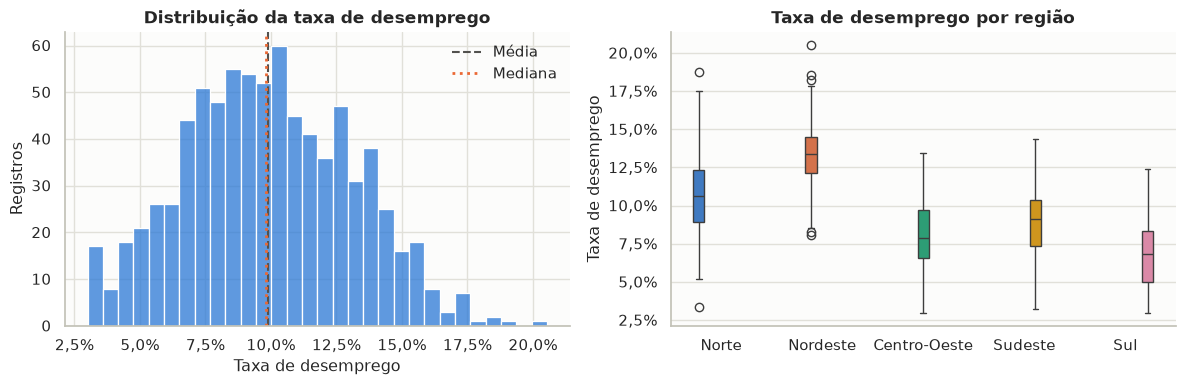

In [20]:
# Distribuição da taxa de desemprego
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["taxa_desemprego"], bins=30, color=AZUL, edgecolor="white", ax=axes[0])
axes[0].axvline(df["taxa_desemprego"].mean(), color=CINZA, ls="--", label="Média")
axes[0].axvline(df["taxa_desemprego"].median(), color="#eb6834", ls=":", lw=2, label="Mediana")
axes[0].set_title("Distribuição da taxa de desemprego")
axes[0].set_xlabel("Taxa de desemprego"); axes[0].set_ylabel("Registros")
axes[0].xaxis.set_major_formatter(PCT); axes[0].legend(frameon=False)

sns.boxplot(data=df, x="regiao", y="taxa_desemprego", hue="regiao", palette=CORES_REGIAO,
            order=ORDEM_REGIOES, legend=False, width=0.55, ax=axes[1])
axes[1].set_title("Taxa de desemprego por região")
axes[1].set_xlabel(""); axes[1].set_ylabel("Taxa de desemprego")
axes[1].yaxis.set_major_formatter(PCT)
sns.despine(fig=fig); fig.tight_layout()
salvar(fig, "distribuicao_taxa")
plt.show()

A distribuição é levemente assimétrica à direita: a maior parte dos registros fica entre 7% e 13%, com uma
cauda de valores altos. O boxplot por região mostra que essa cauda vem quase toda do **Nordeste**, enquanto
o **Sul** concentra as menores taxas.

In [21]:
# Médias por região, estado e setor
resumo_regiao = (df.groupby("regiao", observed=True)
                 .agg(taxa_media=("taxa_desemprego", "mean"), renda_media=("renda_media", "mean"),
                      inflacao_media=("inflacao", "mean"), estados=("uf", "nunique"))
                 .sort_values("taxa_media", ascending=False))
resumo_regiao

,taxa_media,renda_media,inflacao_media,estados
regiao,,,,
Nordeste,13.28,"2,813.59",5.02,5
Norte,10.77,"2,749.51",4.93,4
Sudeste,9.02,"2,782.78",4.82,4
Centro-Oeste,8.03,"2,780.78",5.04,4
Sul,6.79,"2,830.93",5.11,3


In [22]:
resumo_uf = (df.groupby(["uf", "estado", "regiao"], observed=True)
             .agg(taxa_media=("taxa_desemprego", "mean"), taxa_max=("taxa_desemprego", "max"),
                  renda_media=("renda_media", "mean"),
                  trimestres_criticos=("nivel_risco", lambda s: (s == "Crítico").sum()))
             .sort_values("taxa_media", ascending=False).reset_index())
resumo_uf

,uf,estado,regiao,taxa_media,taxa_max,renda_media,trimestres_criticos
0,CE,Ceará,Nordeste,13.65,18.57,"2,848.04",18
1,PB,Paraíba,Nordeste,13.47,20.53,"2,886.69",16
2,BA,Bahia,Nordeste,13.35,17.60,"2,887.65",20
3,PE,Pernambuco,Nordeste,13.24,17.39,"2,710.28",11
4,MA,Maranhão,Nordeste,12.67,18.25,"2,735.30",9
5,TO,Tocantins,Norte,10.98,18.78,"2,599.67",6
6,PA,Pará,Norte,10.80,15.46,"2,793.85",4
7,AM,Amazonas,Norte,10.71,15.53,"2,795.91",3
8,RO,Rondônia,Norte,10.58,16.60,"2,808.60",3
9,RJ,Rio de Janeiro,Sudeste,9.49,13.11,"2,778.10",0


In [23]:
df.groupby("setor_predominante")["taxa_desemprego"].agg(["mean", "median", "std", "count"]).sort_values("mean", ascending=False)

,mean,median,std,count
setor_predominante,,,,
Construção,10.05,10.16,3.14,195
Comércio,9.92,9.62,3.20,155
Agropecuária,9.87,9.73,3.10,147
Indústria,9.82,9.75,3.18,161
Serviços,9.80,9.62,3.58,142


In [24]:
# Frequência dos níveis de risco por região (%)
pd.crosstab(df["regiao"], df["nivel_risco"], normalize="index").mul(100).round(1)

nivel_risco,Baixo,Médio,Alto,Crítico
regiao,,,,
Norte,4.40,34.40,51.20,10.00
Nordeste,0.00,7.00,56.00,37.00
Centro-Oeste,31.20,48.10,20.60,0.00
Sudeste,18.80,46.90,33.10,1.20
Sul,52.50,40.00,7.50,0.00


## 8. KPIs

In [25]:
serie_trimestral = df.groupby("data")["taxa_desemprego"].mean()
anos_decorridos = (serie_trimestral.index - serie_trimestral.index[0]).days / 365.25
inclinacao = np.polyfit(anos_decorridos, serie_trimestral.values, 1)[0]
ultimo = df[df["data"] == df["data"].max()]
taxa_uf = df.groupby("estado")["taxa_desemprego"].mean().sort_values(ascending=False)
taxa_regiao = df.groupby("regiao", observed=True)["taxa_desemprego"].mean().sort_values(ascending=False)

kpis = {
    "Taxa média de desemprego": f"{br(df['taxa_desemprego'].mean())}%",
    "Taxa ponderada pela população ativa": f"{br(df['desempregados'].sum() / df['populacao_ativa'].sum() * 100)}%",
    "Estado com maior desemprego": f"{taxa_uf.index[0]} ({br(taxa_uf.iloc[0])}%)",
    "Estado com menor desemprego": f"{taxa_uf.index[-1]} ({br(taxa_uf.iloc[-1])}%)",
    "Região mais afetada": f"{taxa_regiao.index[0]} ({br(taxa_regiao.iloc[0])}%)",
    "Total de desempregados (soma 2015 a 2024)": f"{br(df['desempregados'].sum() / 1e6)} milhões",
    "Desempregados no último trimestre (2024-T4)": f"{br(ultimo['desempregados'].sum() / 1e6)} milhões",
    "Renda média nacional": f"R$ {br(df['renda_media'].mean())}",
    "Evolução da taxa (2015-T1 a 2024-T4)": f"{br(serie_trimestral.iloc[0])}% -> {br(serie_trimestral.iloc[-1])}% "
                                             f"({br(serie_trimestral.iloc[-1] - serie_trimestral.iloc[0])} p.p.)",
    "Tendência linear": f"{br(inclinacao)} p.p. por ano",
    "Mediana nacional (curiosidade)": f"{br(df['taxa_desemprego'].median())}%",
}
pd.Series(kpis, name="Valor").to_frame()

,Valor
Taxa média de desemprego,"9,90%"
Taxa ponderada pela população ativa,"9,86%"
Estado com maior desemprego,"Ceará (13,65%)"
Estado com menor desemprego,"Paraná (6,71%)"
Região mais afetada,"Nordeste (13,28%)"
Total de desempregados (soma 2015 a 2024),"253,84 milhões"
Desempregados no último trimestre (2024-T4),"5,37 milhões"
Renda média nacional,"R$ 2.790,65"
Evolução da taxa (2015-T1 a 2024-T4),"10,36% -> 8,48% (-1,88 p.p.)"
Tendência linear,"-0,16 p.p. por ano"


**Observações sobre os KPIs**

* A **taxa média** é a média simples das taxas (definição do Tema). A taxa ponderada pela população ativa
  dá mais peso a estados grandes e serve como complemento.
* O **total de desempregados** é a soma de todos os registros, como define o Tema. Como a mesma pessoa pode
  ser contada em vários trimestres, o valor do último trimestre complementa a leitura com um retrato atual.
* A **mediana nacional** (curiosidade) é o valor do meio das taxas. Como fica um pouco abaixo da média, alguns
  registros com taxas muito altas puxam a média para cima.
* A **evolução da taxa** compara o primeiro com o último trimestre e a tendência linear resume a direção de
  todo o período.

## 9. Gráficos

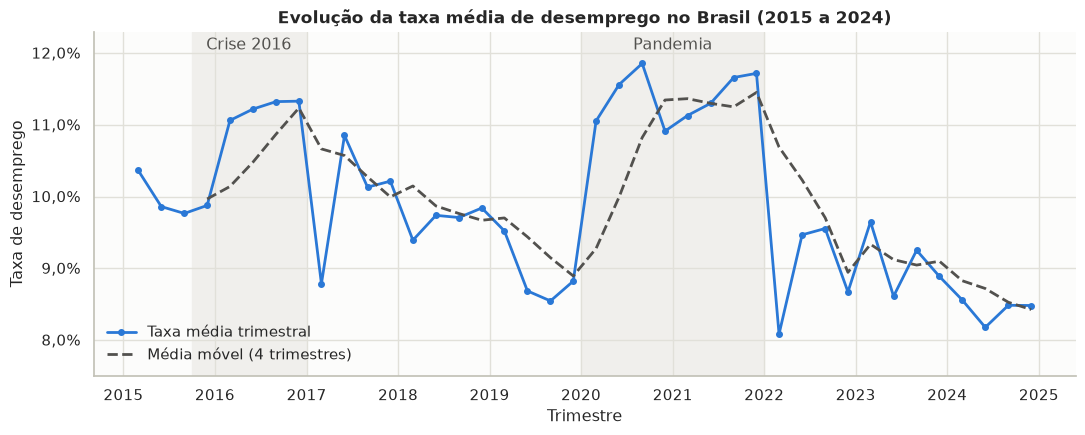

In [26]:
# 9.1 Linha temporal
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axvspan(pd.Timestamp("2015-10-01"), pd.Timestamp("2016-12-31"), color="#f0efec", zorder=0)
ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color="#f0efec", zorder=0)
ax.plot(serie_trimestral.index, serie_trimestral.values, color=AZUL, lw=2, marker="o", ms=4,
        label="Taxa média trimestral")
ax.plot(serie_trimestral.index, serie_trimestral.rolling(4).mean(), color=CINZA, lw=2, ls="--",
        label="Média móvel (4 trimestres)")
ax.text(pd.Timestamp("2016-05-15"), 12.05, "Crise 2016", ha="center", color=CINZA)
ax.text(pd.Timestamp("2021-01-01"), 12.05, "Pandemia", ha="center", color=CINZA)
ax.set_ylim(7.5, 12.3)
ax.set_title("Evolução da taxa média de desemprego no Brasil (2015 a 2024)")
ax.set_xlabel("Trimestre"); ax.set_ylabel("Taxa de desemprego")
ax.yaxis.set_major_formatter(PCT); ax.legend(frameon=False, loc="lower left")
sns.despine(fig=fig); fig.tight_layout()
salvar(fig, "linha_temporal")
plt.show()

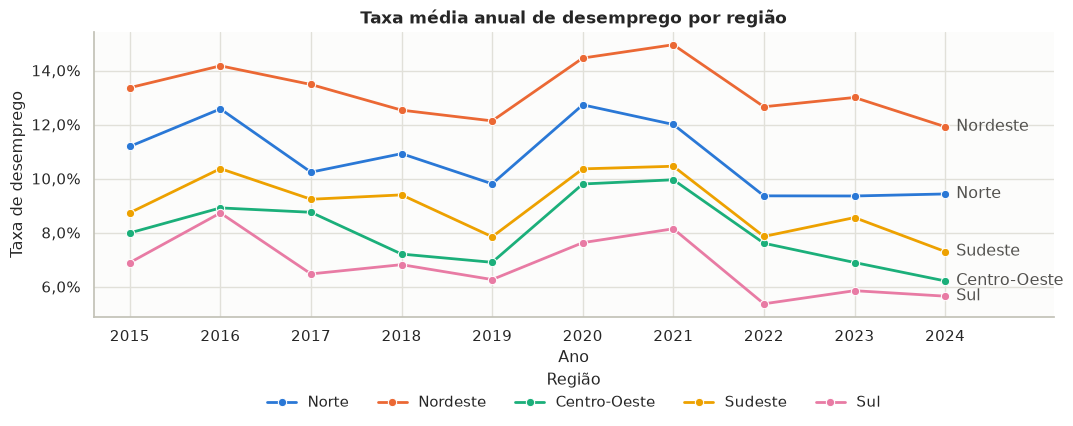

In [27]:
# 9.2 Evolução por região
anual_regiao = df.groupby(["ano", "regiao"], observed=True)["taxa_desemprego"].mean().reset_index()
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.lineplot(data=anual_regiao, x="ano", y="taxa_desemprego", hue="regiao", palette=CORES_REGIAO,
             hue_order=ORDEM_REGIOES, marker="o", lw=2, ax=ax)
for regiao, grupo in anual_regiao.groupby("regiao", observed=True):
    ax.annotate(regiao, (2024, grupo["taxa_desemprego"].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", color=CINZA)
ax.set_xlim(2014.6, 2025.2); ax.set_xticks(range(2015, 2025))
ax.set_title("Taxa média anual de desemprego por região")
ax.set_xlabel("Ano"); ax.set_ylabel("Taxa de desemprego")
ax.yaxis.set_major_formatter(PCT); ax.legend(title="Região", frameon=False, ncol=5, loc="upper center",
                                              bbox_to_anchor=(0.5, -0.15))
sns.despine(fig=fig); fig.tight_layout()
salvar(fig, "linha_regioes")
plt.show()

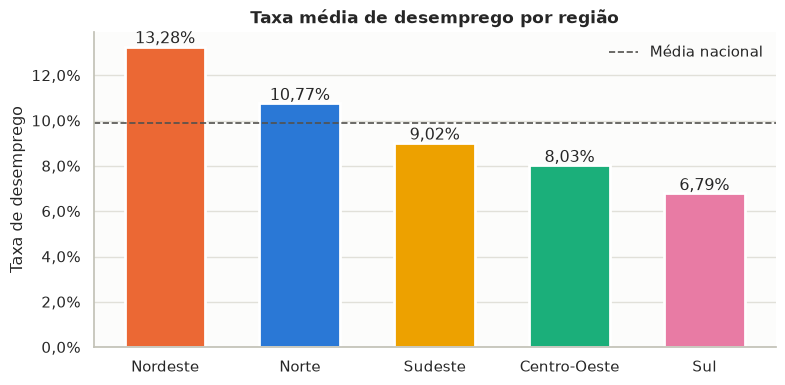

In [28]:
# 9.3 Barras por região
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(taxa_regiao.index.astype(str), taxa_regiao.values, color=[CORES_REGIAO[r] for r in taxa_regiao.index],
       width=0.6, edgecolor="white", linewidth=2)
for x, v in enumerate(taxa_regiao.values):
    ax.text(x, v + 0.15, f"{br(v)}%", ha="center")
ax.axhline(df["taxa_desemprego"].mean(), color=CINZA, ls="--", lw=1.2, label="Média nacional")
ax.set_title("Taxa média de desemprego por região")
ax.set_ylabel("Taxa de desemprego"); ax.yaxis.set_major_formatter(PCT)
ax.grid(axis="x", visible=False); ax.legend(frameon=False)
sns.despine(fig=fig); fig.tight_layout()
salvar(fig, "barras_regiao")
plt.show()

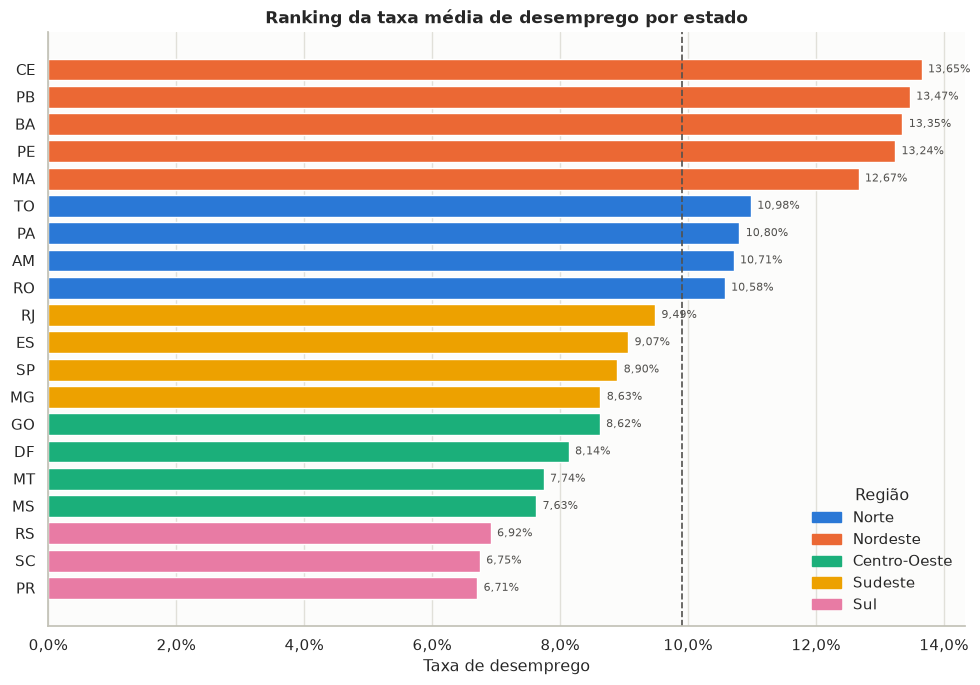

In [29]:
# 9.4 Barras por estado (ranking)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(resumo_uf["uf"], resumo_uf["taxa_media"], color=resumo_uf["regiao"].map(CORES_REGIAO),
        edgecolor="white", linewidth=1)
ax.invert_yaxis()
for y, v in enumerate(resumo_uf["taxa_media"]):
    ax.text(v + 0.1, y, f"{br(v)}%", va="center", fontsize=8, color=CINZA)
ax.axvline(df["taxa_desemprego"].mean(), color=CINZA, ls="--", lw=1.2)
alcas = [plt.Rectangle((0, 0), 1, 1, color=CORES_REGIAO[r]) for r in ORDEM_REGIOES]
ax.legend(alcas, ORDEM_REGIOES, title="Região", frameon=False, loc="lower right")
ax.set_title("Ranking da taxa média de desemprego por estado")
ax.set_xlabel("Taxa de desemprego"); ax.xaxis.set_major_formatter(PCT)
ax.grid(axis="y", visible=False)
sns.despine(fig=fig); fig.tight_layout()
salvar(fig, "barras_estado")
plt.show()

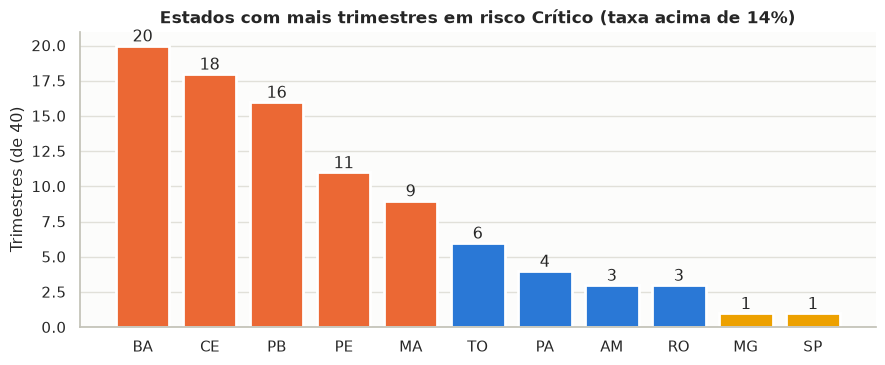

,uf,regiao,trimestres_criticos
1,BA,Nordeste,20
2,CE,Nordeste,18
6,PB,Nordeste,16
7,PE,Nordeste,11
3,MA,Nordeste,9
10,TO,Norte,6
5,PA,Norte,4
0,AM,Norte,3
8,RO,Norte,3
4,MG,Sudeste,1


In [30]:
# 9.5 Ranking de estados críticos
criticos = (df[df["nivel_risco"] == "Crítico"].groupby(["uf", "regiao"], observed=True).size()
            .rename("trimestres_criticos").reset_index().sort_values("trimestres_criticos", ascending=False))
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(criticos["uf"], criticos["trimestres_criticos"], color=criticos["regiao"].map(CORES_REGIAO),
       edgecolor="white", linewidth=2)
for x, v in enumerate(criticos["trimestres_criticos"]):
    ax.text(x, v + 0.3, str(v), ha="center")
ax.set_title("Estados com mais trimestres em risco Crítico (taxa acima de 14%)")
ax.set_ylabel("Trimestres (de 40)"); ax.grid(axis="x", visible=False)
sns.despine(fig=fig); fig.tight_layout()
salvar(fig, "ranking_criticos")
plt.show()
criticos

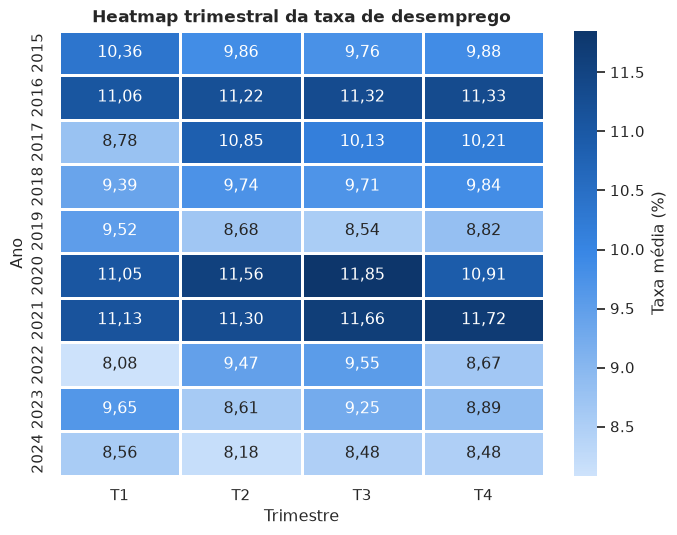

In [31]:
# 9.6 Heatmap trimestral
heat = df.pivot_table(index="ano", columns="trimestre", values="taxa_desemprego", aggfunc="mean")
heat.columns = [f"T{c}" for c in heat.columns]
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(heat, annot=anot(heat, 2), fmt="", cmap=CMAP_SEQ, linewidths=2, linecolor="white",
            cbar_kws={"label": "Taxa média (%)"}, ax=ax)
ax.set_title("Heatmap trimestral da taxa de desemprego"); ax.set_xlabel("Trimestre"); ax.set_ylabel("Ano")
fig.tight_layout()
salvar(fig, "heatmap_trimestral")
plt.show()

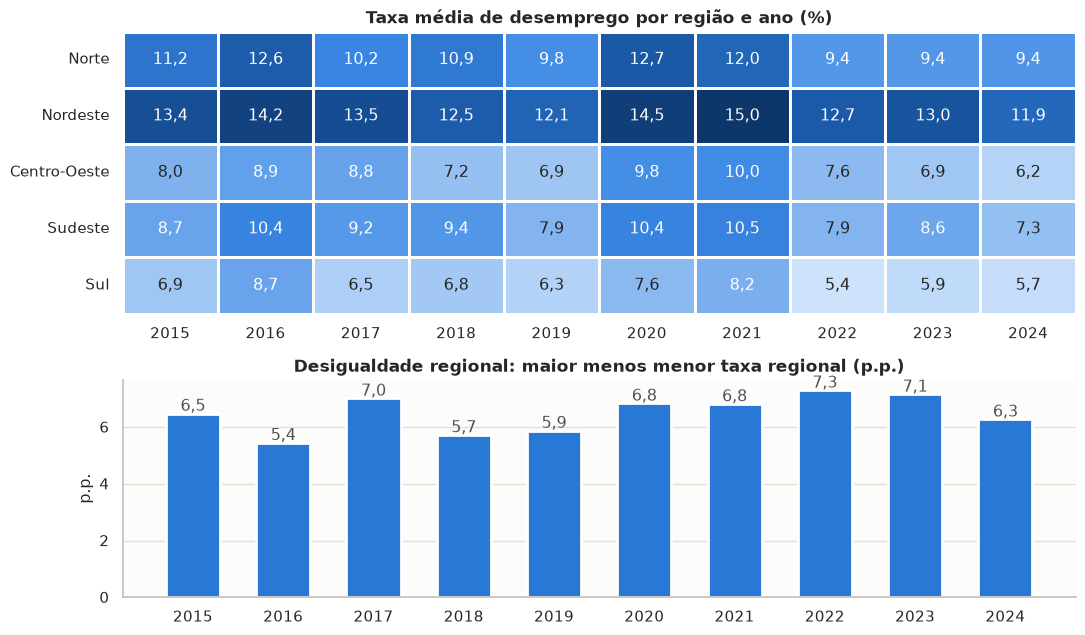

Diferença média entre a região com maior e a com menor taxa: 6,49 p.p.


In [32]:
# 9.7 Heatmap região x ano e desigualdade regional
regiao_ano = df.pivot_table(index="regiao", columns="ano", values="taxa_desemprego", aggfunc="mean", observed=True)
gap = regiao_ano.max() - regiao_ano.min()

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), gridspec_kw={"height_ratios": [1.3, 1]})
sns.heatmap(regiao_ano, annot=anot(regiao_ano, 1), fmt="", cmap=CMAP_SEQ, linewidths=2, linecolor="white",
            cbar=False, ax=axes[0])
axes[0].set_title("Taxa média de desemprego por região e ano (%)"); axes[0].set_xlabel(""); axes[0].set_ylabel("")
axes[1].bar(gap.index, gap.values, color=AZUL, width=0.6, edgecolor="white", linewidth=2)
for x, v in zip(gap.index, gap.values):
    axes[1].text(x, v + 0.1, br(v, 1), ha="center", color=CINZA)
axes[1].set_title("Desigualdade regional: maior menos menor taxa regional (p.p.)")
axes[1].set_xticks(gap.index); axes[1].set_ylabel("p.p."); axes[1].grid(axis="x", visible=False)
sns.despine(ax=axes[1]); fig.tight_layout()
salvar(fig, "desigualdade_regional")
plt.show()
print(f"Diferença média entre a região com maior e a com menor taxa: {br(gap.mean())} p.p.")

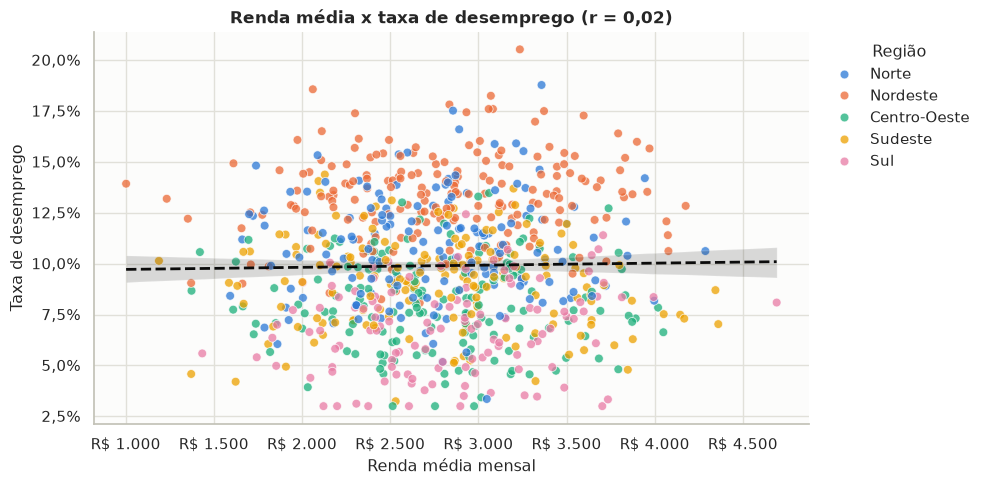

In [33]:
# 9.8 Dispersão renda x desemprego
r_renda = df["renda_media"].corr(df["taxa_desemprego"])
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df, x="renda_media", y="taxa_desemprego", hue="regiao", palette=CORES_REGIAO,
                hue_order=ORDEM_REGIOES, s=40, alpha=0.75, edgecolor="white", linewidth=0.6, ax=ax)
sns.regplot(data=df, x="renda_media", y="taxa_desemprego", scatter=False, color="#0b0b0b",
            line_kws={"lw": 2, "ls": "--"}, ax=ax)
ax.set_title(f"Renda média x taxa de desemprego (r = {br(r_renda)})")
ax.set_xlabel("Renda média mensal"); ax.set_ylabel("Taxa de desemprego")
ax.xaxis.set_major_formatter(MOEDA); ax.yaxis.set_major_formatter(PCT)
ax.legend(title="Região", frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
sns.despine(fig=fig); fig.tight_layout()
salvar(fig, "dispersao_renda")
plt.show()

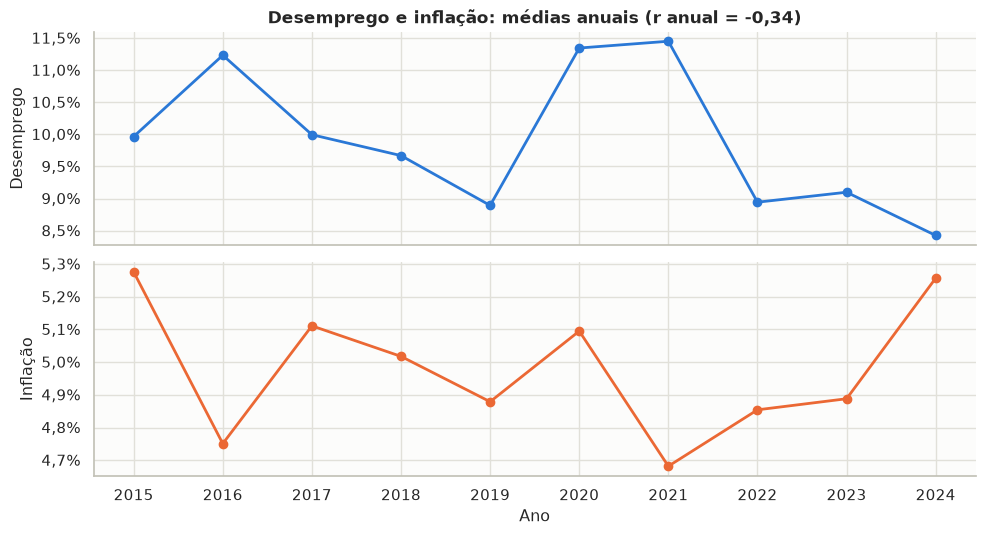

Correlação inflação x desemprego (registros): -0,00 | (médias anuais): -0,34


In [34]:
# 9.9 Inflação x desemprego (dois painéis, mesmo eixo de tempo)
anual = df.groupby("ano")[["taxa_desemprego", "inflacao", "renda_media", "vagas_formais"]].mean()
r_infl = df["inflacao"].corr(df["taxa_desemprego"])
r_infl_anual = anual["inflacao"].corr(anual["taxa_desemprego"])
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
axes[0].plot(anual.index, anual["taxa_desemprego"], color=AZUL, lw=2, marker="o")
axes[0].set_ylabel("Desemprego"); axes[0].yaxis.set_major_formatter(PCT)
axes[0].set_title(f"Desemprego e inflação: médias anuais (r anual = {br(r_infl_anual)})")
axes[1].plot(anual.index, anual["inflacao"], color="#eb6834", lw=2, marker="o")
axes[1].set_ylabel("Inflação"); axes[1].yaxis.set_major_formatter(PCT)
axes[1].set_xticks(anual.index); axes[1].set_xlabel("Ano")
sns.despine(fig=fig); fig.tight_layout()
salvar(fig, "inflacao_desemprego")
plt.show()
print(f"Correlação inflação x desemprego (registros): {br(r_infl)} | (médias anuais): {br(r_infl_anual)}")

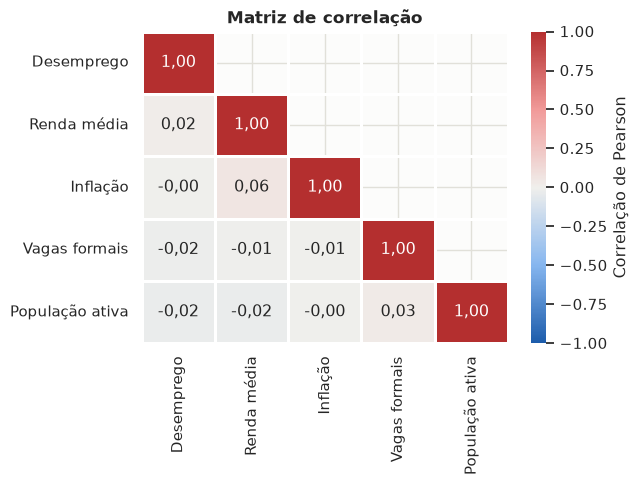

In [35]:
# 9.10 Matriz de correlação
nomes = {"taxa_desemprego": "Desemprego", "renda_media": "Renda média", "inflacao": "Inflação",
         "vagas_formais": "Vagas formais", "populacao_ativa": "População ativa"}
corr = df[list(nomes)].rename(columns=nomes).corr()
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=anot(corr, 2), fmt="",
            cmap=CMAP_DIV, vmin=-1, vmax=1, linewidths=2, linecolor="white",
            cbar_kws={"label": "Correlação de Pearson"}, ax=ax)
ax.set_title("Matriz de correlação")
fig.tight_layout()
salvar(fig, "correlacao")
plt.show()

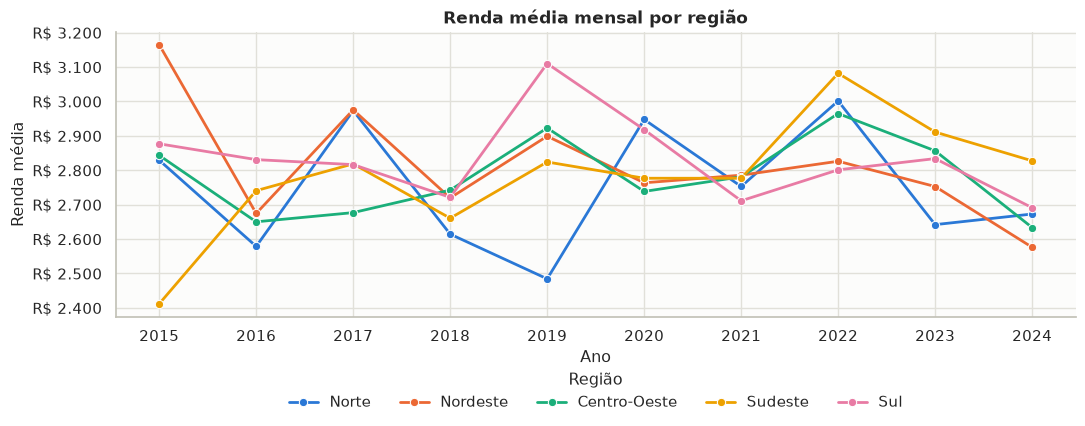

,mean,count
faixa_renda,,
Até R$ 2 mil,9.63,69
R$ 2 a 3 mil,9.79,448
R$ 3 a 4 mil,10.19,270
Acima de R$ 4 mil,9.09,13


In [36]:
# 9.11 Renda média por região ao longo do tempo
renda_regiao = df.groupby(["ano", "regiao"], observed=True)["renda_media"].mean().reset_index()
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.lineplot(data=renda_regiao, x="ano", y="renda_media", hue="regiao", palette=CORES_REGIAO,
             hue_order=ORDEM_REGIOES, marker="o", lw=2, ax=ax)
ax.set_xticks(range(2015, 2025)); ax.yaxis.set_major_formatter(MOEDA)
ax.set_title("Renda média mensal por região"); ax.set_xlabel("Ano"); ax.set_ylabel("Renda média")
ax.legend(title="Região", frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.15))
sns.despine(fig=fig); fig.tight_layout()
salvar(fig, "renda_regiao")
plt.show()
df.groupby("faixa_renda", observed=True)["taxa_desemprego"].agg(["mean", "count"])

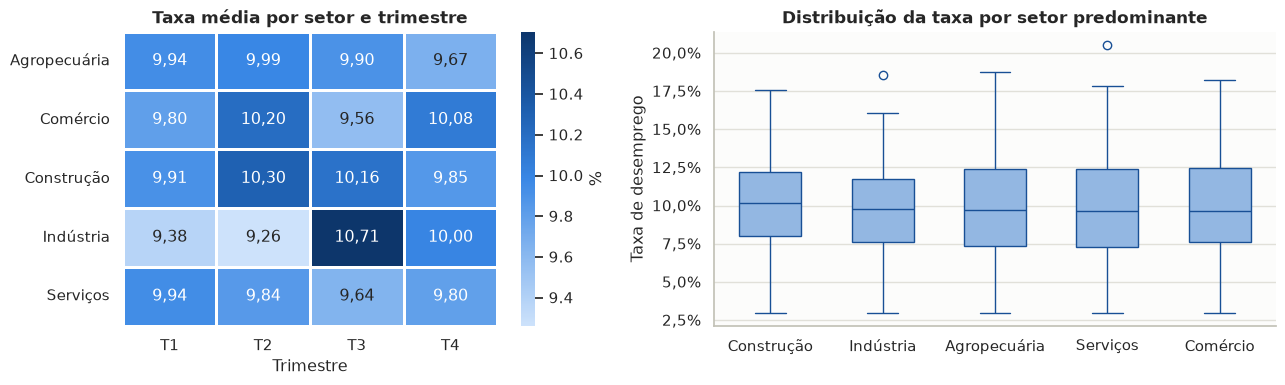

setor_predominante
Indústria      1.45
Comércio       0.64
Construção     0.45
Agropecuária   0.32
Serviços       0.30
Name: amplitude_pp, dtype: float64

In [37]:
# 9.12 Sazonalidade por setor
saz = df.pivot_table(index="setor_predominante", columns="trimestre", values="taxa_desemprego", aggfunc="mean")
saz.columns = [f"T{c}" for c in saz.columns]
fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1, 1.2]})
sns.heatmap(saz, annot=anot(saz, 2), fmt="", cmap=CMAP_SEQ, linewidths=2, linecolor="white",
            cbar_kws={"label": "%"}, ax=axes[0])
axes[0].set_title("Taxa média por setor e trimestre"); axes[0].set_xlabel("Trimestre"); axes[0].set_ylabel("")
ordem_setor = df.groupby("setor_predominante")["taxa_desemprego"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="setor_predominante", y="taxa_desemprego", order=ordem_setor, color="#86b6ef",
            linecolor="#184f95", width=0.55, ax=axes[1])
axes[1].set_title("Distribuição da taxa por setor predominante"); axes[1].set_xlabel("")
axes[1].set_ylabel("Taxa de desemprego"); axes[1].yaxis.set_major_formatter(PCT)
sns.despine(ax=axes[1]); fig.tight_layout()
salvar(fig, "sazonalidade_setor")
plt.show()
(saz.max(axis=1) - saz.min(axis=1)).sort_values(ascending=False).rename("amplitude_pp")

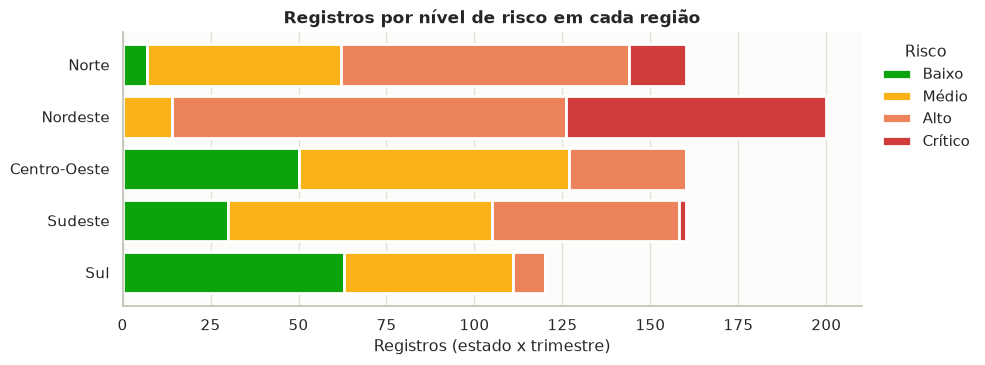

In [38]:
# 9.13 Nível de risco por região
risco = pd.crosstab(df["regiao"], df["nivel_risco"])
fig, ax = plt.subplots(figsize=(10, 3.8))
base = np.zeros(len(risco))
for nivel in ORDEM_RISCO:
    ax.barh(risco.index.astype(str), risco[nivel], left=base, color=CORES_RISCO[nivel], edgecolor="white",
            linewidth=2, label=nivel)
    base += risco[nivel].values
ax.invert_yaxis()
ax.set_title("Registros por nível de risco em cada região")
ax.set_xlabel("Registros (estado x trimestre)")
ax.legend(title="Risco", frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", visible=False)
sns.despine(fig=fig); fig.tight_layout()
salvar(fig, "risco_regiao")
plt.show()

In [39]:
# 9.14 Fases econômicas
fases = (df.groupby("fase_economica")[["taxa_desemprego", "renda_media", "vagas_formais", "inflacao"]].mean()
         .reindex(["Crise 2015-2016", "Pré-pandemia", "Pandemia", "Recuperação"]))
fases

,taxa_desemprego,renda_media,vagas_formais,inflacao
fase_economica,,,,
Crise 2015-2016,10.60,"2,763.23","41,865.96",5.01
Pré-pandemia,9.52,"2,796.22","47,108.27",5.00
Pandemia,11.40,"2,793.00","45,726.15",4.89
Recuperação,8.82,"2,801.80","43,899.55",5.00


## 10. Interpretação dos resultados

**1. Quais regiões apresentam maior desemprego?**
O **Nordeste** tem a maior taxa média (cerca de 13,3%), seguido do **Norte** (cerca de 10,8%). Juntas, essas
duas regiões concentram praticamente todos os registros em risco **Crítico**. O Ceará é o estado com a
maior taxa média.

**2. Quais estados apresentam menores taxas?**
Os três estados do **Sul**: Paraná (6,7%), Santa Catarina (6,8%) e Rio Grande do Sul (6,9%), seguidos de
Mato Grosso do Sul e Mato Grosso. São os estados com maior proporção de trimestres em risco Baixo.

**3. Existem períodos de crise econômica mais evidentes?**
Sim. Há dois picos claros: **2016** (média de 11,2%, reflexo da recessão de 2015 e 2016) e **2020 e 2021**
(11,4% e 11,5%, efeito da pandemia). O heatmap trimestral mostra que o pior momento foi o 3º trimestre de 2020.

**4. O desemprego aumentou ou diminuiu ao longo do tempo?**
Diminuiu. A taxa média caiu de cerca de 10,4% no início de 2015 para cerca de 8,5% no fim de 2024, e 2024 tem a
menor média anual da série (8,4%). A tendência linear é de queda, apesar das duas crises no caminho. Após o
pico da pandemia, a taxa recuou cerca de 3 p.p., caracterizando a **recuperação econômica** de 2022 a 2024.

**5. Existem diferenças relevantes entre regiões?**
Sim, e elas são **estruturais**: a diferença entre a região com maior e a com menor taxa variou entre 5,4 e
7,3 p.p. (média de 6,5 p.p.) e a ordem das regiões foi **idêntica em todos os dez anos**: Nordeste, Norte,
Sudeste, Centro-Oeste e Sul. As crises elevam o desemprego em todas as regiões, mas não mudam essa ordem. Na
recuperação a diferença chegou a aumentar (7,3 p.p. em 2022), porque o Sul se recuperou mais rápido.

**6. Há sazonalidade em determinados setores?**
A sazonalidade é fraca. O setor com maior oscilação entre trimestres é a **Indústria**, com pico no 3º
trimestre (cerca de 1,5 p.p. acima do melhor trimestre). Nos demais setores a diferença entre trimestres fica
abaixo de 0,7 p.p. As médias por setor também são muito próximas (9,8% a 10,1%).

**7. Quais grupos parecem mais vulneráveis?**
Os estados do **Nordeste** (todos com taxa média acima de 12,5%) e, em segundo plano, os do **Norte**. A faixa
de renda e o setor predominante mostram diferenças pequenas, o que indica que, nesta base, a **localização
geográfica** é o fator que mais separa os grupos vulneráveis.

**Relação com variáveis econômicas**
As correlações de Pearson entre desemprego e renda média, inflação e vagas formais são próximas de zero no nível
dos registros. Nos dados simulados essas variáveis variam de forma quase independente da taxa, então não
devem ser lidas como causa do desemprego. Com médias anuais, inflação e desemprego têm correlação negativa
fraca a moderada (r = -0,34): anos de inflação um pouco maior tiveram desemprego um pouco menor, mas com apenas
10 pontos esse resultado é frágil. Na economia real, por exemplo, a relação entre inflação e desemprego
(curva de Phillips) costuma aparecer apenas em determinados períodos.

## 11. Conclusão

* O desemprego no período analisado teve **trajetória de queda**, interrompida por duas crises bem
  identificáveis: a recessão de 2015 e 2016 e a pandemia de 2020 e 2021.
* A **recuperação** a partir de 2022 levou a taxa ao menor nível da série em 2024.
* A **desigualdade regional é o traço mais forte** da base: o Nordeste mantém taxas cerca de duas vezes
  maiores que o Sul, a ordem entre as regiões é a mesma em todos os anos e a diferença não diminuiu com a
  recuperação.
* Setor predominante, renda e inflação têm pouca relação com a taxa nesta base, o que reforça que políticas
  de emprego precisam de **foco regional**, priorizando Nordeste e Norte.

Os dados tratados e o banco SQLite gerados neste notebook alimentam o dashboard Streamlit, onde todos esses
resultados podem ser explorados com filtros por ano, trimestre, região, estado, setor e nível de risco.